## Desafío 3

##### Configuración inicial

In [1]:
import pandas as pd
from tensorflow import keras
from keras import Input
from tensorflow.keras.preprocessing.text import Tokenizer, text_to_word_sequence
from tensorflow.keras.utils import pad_sequences
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr


### Datos
Utilizaré como dataset letras de temas de Charly Garcia

In [2]:
df = pd.read_csv('datasets/letras_charly.csv', usecols=['verso']).dropna().drop_duplicates()

print("Cantidad de versos:", df.shape[0])
df.head()

Cantidad de versos: 5454


,verso
0,Podés pasear en limousine
1,cortar las flores del jardín
2,podés cambiar el sol
3,y esconderte si no quieres verme.
4,Puedes ver amanecer


In [3]:
corpus = []

# 1. Tokenizar cada texto en palabras
for _, row in df[:None].iterrows():
    corpus.append(text_to_word_sequence(row.iloc[0]))

# 2. Aplanar todas las palabras en una sola lista
flattened = [palabra for frase in corpus for palabra in frase]

# 3. Convertir cada palabra a lista de caracteres
corpus = [list(palabra) for palabra in flattened]

print(f"El corpus posee {len(corpus)} documentos (palabras). \nPor ejemplo: {corpus[0:9]}")


El corpus posee 27867 documentos (palabras). 
Por ejemplo: [['p', 'o', 'd', 'é', 's'], ['p', 'a', 's', 'e', 'a', 'r'], ['e', 'n'], ['l', 'i', 'm', 'o', 'u', 's', 'i', 'n', 'e'], ['c', 'o', 'r', 't', 'a', 'r'], ['l', 'a', 's'], ['f', 'l', 'o', 'r', 'e', 's'], ['d', 'e', 'l'], ['j', 'a', 'r', 'd', 'í', 'n']]


Calcularé el tamaño del contexto según la distribución de longitudes de las palabras

(array([1.454e+03, 0.000e+00, 7.328e+03, 0.000e+00, 4.926e+03, 0.000e+00,
        3.856e+03, 0.000e+00, 3.746e+03, 0.000e+00, 2.574e+03, 0.000e+00,
        1.747e+03, 0.000e+00, 1.030e+03, 0.000e+00, 6.400e+02, 0.000e+00,
        2.820e+02, 0.000e+00, 1.720e+02, 0.000e+00, 5.700e+01, 0.000e+00,
        3.000e+01, 0.000e+00, 1.100e+01, 0.000e+00, 1.200e+01, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([ 1.        ,  1.48571429,  1.97142857,  2.45714286,  2.94285714,
         3.42857143,  3.91428571,  4.4       ,  4.88571429,  5.37142857,
         5.85714286,  6.34285714,  6.82857143,  7.31428571,  7.8       ,
         8.28571429,  8.77142857,  9.25714286,  9.74285714, 10.22857143,
        10.71428571, 11.2       , 11.68571429, 12.17142857, 12.65714286,
        13.14285714, 13.62857143, 14.11428571, 14.6       , 15.08571429,
        15.57142857, 16.05714286, 16.54285714, 17.02857143, 17.51428571,
        18.        ]),
 <BarContainer object of 35 art

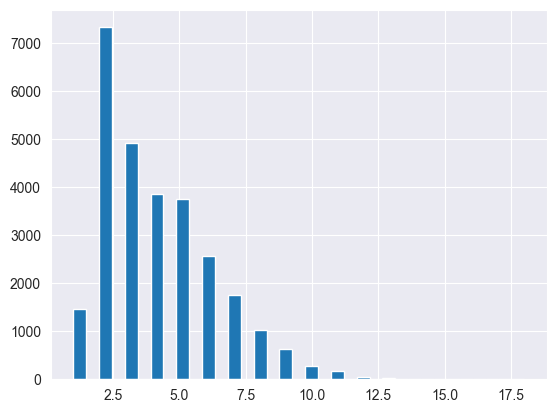

In [4]:
# calculamos la longitud de cada secuencia
length_secuence = [len(secuence) for secuence in corpus]
plt.hist(length_secuence,bins=35)


In [5]:
max_context_size = 6

Ahora tokenizaré cada una de las letras

In [6]:
tok = Tokenizer()
tok.fit_on_texts(corpus)
tokenized_corpus = tok.texts_to_sequences(corpus)

print(tokenized_corpus[0:9])

[[14, 3, 11, 26, 4], [14, 2, 4, 1, 2, 6], [1, 5], [8, 7, 12, 3, 10, 4, 7, 5, 1], [13, 3, 6, 9, 2, 6], [8, 2, 4], [21, 8, 3, 6, 1, 4], [11, 1, 8], [27, 2, 6, 11, 23, 5]]


Separamos sets de entrenamiento y validación

In [7]:
train, val, _, _ = train_test_split(tokenized_corpus, tokenized_corpus, test_size=0.2, random_state=42)
train

[[18, 10, 7, 1, 5],
 [4, 7, 1, 12, 14, 6, 1],
 [5, 3],
 [6, 1, 16, 7, 4, 9, 2, 4],
 [11, 1, 8],
 [17, 2, 20, 23, 2],
 [12, 23],
 [12, 1],
 [11, 1],
 [8, 8],
 [12, 2, 19, 11, 2, 8, 1, 5, 2],
 [4, 1, 2, 12, 3, 4],
 [29, 5, 3, 28],
 [12, 7, 8],
 [10, 5],
 [21, 7, 6, 1],
 [15, 3, 10],
 [28, 2, 4],
 [1, 21, 7, 13, 2, 25],
 [9, 1],
 [11, 1],
 [28, 3, 6, 8, 11],
 [9, 10],
 [17, 3, 15],
 [1, 5, 9, 7, 6, 1],
 [1, 5, 9, 1, 5, 11, 1, 6],
 [4, 1, 5, 9, 7, 6],
 [12, 15],
 [2, 5, 2, 4, 9, 2, 4, 7, 2],
 [4, 24, 8, 3],
 [10, 12],
 [11, 3, 8, 3, 6],
 [14, 7, 1, 5, 4, 2, 5],
 [2],
 [17, 2, 20, 8, 2, 5, 11, 3],
 [9, 10],
 [9, 3, 11, 3, 4],
 [1, 5],
 [5, 3],
 [20, 1],
 [16, 7, 16, 7, 6],
 [14, 1, 6, 3],
 [2, 5, 11],
 [18, 10, 1],
 [12, 1],
 [13, 3, 12, 3],
 [16, 1, 5, 7, 6],
 [14, 7, 1, 11, 6, 2, 4],
 [1, 8],
 [11, 3, 12, 7, 5, 19, 3, 4],
 [18, 10, 1],
 [14, 1, 6, 11, 24, 5],
 [14, 2, 19, 24],
 [9, 3, 11, 3],
 [2, 32, 3, 4],
 [9, 10],
 [17, 3, 5, 19, 3, 4],
 [28, 2, 9, 13, 17, 1, 11],
 [11, 1, 8],
 [2, 13

Realizamos un padding para ajustar al máximo valor de contexto

In [8]:
def seq_of(set):
    train_seq = []

    for word in set:
        train_seq.append(pad_sequences([word], maxlen=max_context_size+1, padding='pre'))
    train_seqs = np.concatenate(train_seq, axis=0)
    return train_seqs, train_seqs[:, :-1], train_seqs[:, -1]

In [9]:
train_seqs, X, y = seq_of(train)
print(f'training shape {train_seqs.shape}')
print(f'datos (X): {X[0]} ({ "".join([ tok.index_word.get(c,"") for c in X[0]]) })')
print(f'predicción (y): {y[0]} ({tok.index_word[y[0]]})')

training shape (22293, 7)
datos (X): [ 0  0 18 10  7  1] (quie)
predicción (y): 5 (n)


In [10]:
vocab_size = len(tok.word_counts)
print(f'Tamaño del vocabulario: {vocab_size} \n')
print(f'Vocabulario: {tok.word_index} \n')
print(f'Vocabulario por apariciones: {tok.word_docs}')

Tamaño del vocabulario: 56 

Vocabulario: {'e': 1, 'a': 2, 'o': 3, 's': 4, 'n': 5, 'r': 6, 'i': 7, 'l': 8, 't': 9, 'u': 10, 'd': 11, 'm': 12, 'c': 13, 'p': 14, 'y': 15, 'v': 16, 'h': 17, 'q': 18, 'g': 19, 'b': 20, 'f': 21, 'á': 22, 'í': 23, 'ó': 24, 'z': 25, 'é': 26, 'j': 27, 'w': 28, 'k': 29, '́': 30, '\x92': 31, 'ñ': 32, 'x': 33, 'ú': 34, '¿': 35, "'": 36, '’': 37, '\x93': 38, '\x94': 39, '¡': 40, '\x97': 41, 'ã': 42, '2': 43, '3': 44, '´': 45, '0': 46, '̃': 47, 'ü': 48, '\x85': 49, '7': 50, '1': 51, '5': 52, '4': 53, '9': 54, 'ç': 55, 'ô': 56} 

Vocabulario por apariciones: defaultdict(<class 'int'>, {'o': 9396, 'p': 2452, 'd': 4491, 'é': 493, 's': 7401, 'r': 6301, 'e': 12536, 'a': 10146, 'n': 7296, 'm': 3673, 'u': 5115, 'i': 5461, 'l': 4945, 'c': 3116, 't': 5076, 'f': 790, 'í': 629, 'j': 487, 'b': 1338, 'y': 2394, 'q': 1648, 'v': 1645, 'h': 1690, 'g': 1422, 'ó': 518, 'ñ': 149, 'z': 495, 'á': 677, '3': 3, 'ú': 71, 'x': 84, 'w': 355, 'k': 212, '¿': 49, '¡': 14, '\x93': 15, '\x94': 15

Se pueden ver como se colaron ciertos caracteres que no pertenecen al idioma español y caracteres especiales. Esto nos indica que el dataset podría necesitar cierto tratamiento. Ya sea eliminando estos caracteres como también eliminando canciones que no estén en español. 

### Modelo

In [11]:
model = Sequential()

model.add(Input(shape=(max_context_size,)))
model.add(Embedding(input_dim=vocab_size+1, output_dim=50))
model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(64))
model.add(Dense(32, activation='relu'))
model.add(Dense(vocab_size+1, activation='softmax'))
model.compile(loss=SparseCategoricalCrossentropy(), optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 6, 50)          │         2,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 6, 64)          │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 57)             │         1,881 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,275 (270.61 KB)

 Trainable params: 69,275 (270.61 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
class PerplexityCallback(keras.callbacks.Callback):
    def __init__(self, validation_data=None):
        super().__init__()
        self.validation_data = validation_data  # no hace falta si usás logs['val_loss']

    def on_epoch_end(self, epoch, logs=None):
        if logs is None:
            logs = {}

        # Calcular y mostrar perplexity en entrenamiento
        train_loss = logs.get('loss')
        if train_loss is not None:
            train_perplexity = np.exp(train_loss)
            logs['perplexity'] = train_perplexity
            print(f'\n📚 Training Perplexity: {train_perplexity:.4f}')

        # Calcular y mostrar perplexity en validación
        val_loss = logs.get('val_loss')
        if val_loss is not None:
            val_perplexity = np.exp(val_loss)
            logs['val_perplexity'] = val_perplexity
            print(f'🔎 Validation Perplexity: {val_perplexity:.4f}')


In [13]:
_, X_val, y_val = seq_of(val)

hist = model.fit(X, y, epochs=50, validation_data=(X_val, y_val), callbacks=[PerplexityCallback()],  batch_size=300)

Epoch 1/50
71/75 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1304 - loss: 3.5526
📚 Training Perplexity: 20.6803
🔎 Validation Perplexity: 12.1568
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1323 - loss: 3.5185 - val_accuracy: 0.1765 - val_loss: 2.4979 - perplexity: 20.6803 - val_perplexity: 12.1568
Epoch 2/50
73/75 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1862 - loss: 2.4622
📚 Training Perplexity: 11.6433
🔎 Validation Perplexity: 11.2222
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1866 - loss: 2.4619 - val_accuracy: 0.2106 - val_loss: 2.4179 - perplexity: 11.6433 - val_perplexity: 11.2222
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2361 - loss: 2.3761
📚 Training Perplexity: 10.0516
🔎 Validation Perplexity: 8.1219
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2365 - loss: 2.3752 - val_accuracy: 0.3143 - val_loss: 2.0946 - perplexity: 10.0516 - val_perplexity: 8.1219
Epoch 4/50
73/75 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 

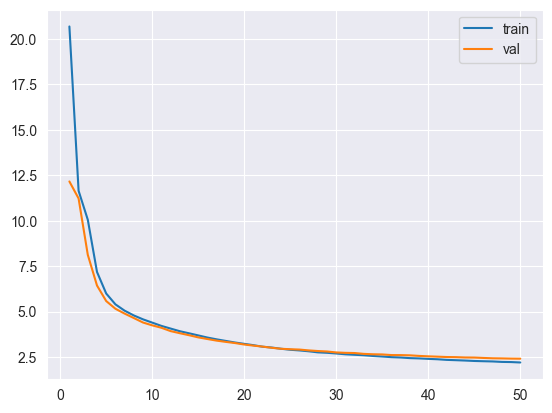

In [14]:
# Entrenamiento
epoch_count = range(1, len(hist.history['perplexity']) + 1)
sns.lineplot(x=epoch_count,  y=hist.history['perplexity'], label='train')
sns.lineplot(x=epoch_count,  y=hist.history['val_perplexity'], label='val')
plt.show()

In [26]:
def generate_seq(model, tokenizer, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            tokenizer (keras tokenizer): tonenizer utilizado en el preprocesamiento
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de palabras a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
    # generate a fixed number of words
    for _ in range(n_words):
        # Encodeamos
        encoded = tokenizer.texts_to_sequences([output_text])[0]
        # Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

        # Predicción softmax
        y_hat = model.predict(encoded).argmax(axis=-1)
        # Vamos concatenando las predicciones
        out_word = ''

        # Debemos buscar en el vocabulario la palabra
        # que corresopnde al indice (y_hat) predicho por le modelo
        for word, index in tokenizer.word_index.items():
            if index == y_hat:
                out_word = word
                break

            # Agrego las palabras a la frase predicha
        output_text += ' ' + out_word
    return output_text

In [27]:
input_text='El tigre se encontró con'

generate_seq(model, tok, input_text, max_length=max_context_size, n_words=13)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


'El tigre se encontró con y o u r d e s o s e s a s'

Si bien el modelo logra predecir el siguiente caracter no logré que las secuencias creadas construyan palabras que tengan sentido